# Enterprise Private GPT — отчёт

**Домашнее задание OTUS.** Защищённый корпоративный чат-бот (RAG-система) на
полностью локальных ресурсах: LLM, эмбеддинги и векторная база данных работают
на машине пользователя, без внешних платных API и без утечки данных.

В отчёте: архитектура, стек, пайплайн обработки документов, живая демонстрация
ответов, анализ Top-K и latency, скриншоты интерфейса и выводы.


## 1. Архитектура

```
                 ┌──────────────────────────┐
                 │        OpenWebUI          │  http://127.0.0.1:8080
                 │  (чат-интерфейс, браузер) │
                 └────────────┬─────────────┘
                              │ OpenAI API
                 ┌────────────▼─────────────┐
                 │   FastAPI RAG-шлюз        │  http://127.0.0.1:8000/v1
                 │  retrieval → prompt → LLM │
                 └───────┬───────────┬──────┘
                         │           │
        ┌────────────────▼──┐   ┌────▼──────────────────┐
        │   ChromaDB        │   │   Ollama              │
        │ (вектора + meta)  │   │ qwen2.5:3b-instruct   │
        └────────▲──────────┘   └───────────────────────┘
                 │ эмбеддинги
        ┌────────┴───────────────────┐
        │ intfloat/multilingual-e5   │
        │ (sentence-transformers)    │
        └────────────────────────────┘
```

Поток данных: документы → очистка → чанкование → эмбеддинги → ChromaDB.
Запрос → эмбеддинг → поиск top-K → системный промпт с контекстом → локальная
LLM → ответ со ссылками на источники файлов.


## 2. Стек и обоснование выбора

| Компонент | Выбор | Почему |
|---|---|---|
| LLM | **Qwen2.5-3B-Instruct** (Ollama) | Хорошая поддержка русского, лёгкая для CPU, ставится одной командой |
| Эмбеддинги | **intfloat/multilingual-e5-small** | Мультиязычная, качественная для русского, быстрая на CPU |
| Векторная БД | **ChromaDB** | Простое локальное персистентное хранилище с метаданными |
| Оркестрация | **LangChain** | Загрузка, чанкование, retriever, промпты |
| Интерфейс | **OpenWebUI** | Готовый чат, подключается к любому OpenAI-совместимому API |
| Шлюз | **FastAPI + Uvicorn** | Связывает собственный RAG-пайплайн с OpenWebUI |

Аппаратная конфигурация: CPU Intel Core i7-1260P (12 ядер / 16 потоков),
31.7 ГБ RAM, **без дискретного GPU** — поэтому выбрана компактная модель 3B.


## 3. Датасет

Используется **RuLegalNER** — корпус русскоязычных судебных решений
(репозиторий <https://github.com/zeino8/RuLegalNER>). Исходные данные — три CSV
файла без заголовка: колонка 0 — текст документа, колонка 1 — NER-разметка
(отбрасывается). Для демонстрации берётся подвыборка из 400 документов.


In [1]:
import importlib.util
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
SCRIPTS = ROOT / "Scripts"
sys.path.insert(0, str(SCRIPTS))

# config.py лежит в Scripts/
spec = importlib.util.spec_from_file_location("config", SCRIPTS / "config.py")
config = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config)

print(f"Проект:            {ROOT}")
print(f"LLM:               {config.LLM_MODEL}  ({config.OLLAMA_BASE_URL})")
print(f"Эмбеддинги:        {config.EMBEDDING_MODEL}")
print(f"chunk_size:        {config.CHUNK_SIZE}")
print(f"chunk_overlap:     {config.CHUNK_OVERLAP}")
print(f"top_K:             {config.TOP_K}")
print(f"Коллекция Chroma:  {config.COLLECTION_NAME}")

Проект:            C:\Users\SEA6352\Documents\Open Code Work\otus_learning\hw4
LLM:               qwen2.5:3b-instruct  (http://localhost:11434)
Эмбеддинги:        intfloat/multilingual-e5-small
chunk_size:        800
chunk_overlap:     150
top_K:             4
Коллекция Chroma:  corporate_legal


In [2]:
processed = config.DATA_PROCESSED
docs = sorted(processed.glob("*.txt")) if processed.exists() else []
print(f"Документов в data/processed: {len(docs)}")
if (processed / 'manifest.jsonl').exists():
    manifest = [json.loads(l) for l in (processed / 'manifest.jsonl').read_text(encoding='utf-8').splitlines()]
    total_chars = sum(m['n_chars'] for m in manifest)
    print(f"Суммарный объём текста:      {total_chars/1e6:.2f} млн символов")
    print(f"Средняя длина документа:     {total_chars//max(1,len(manifest))} символов")

Документов в data/processed: 400
Суммарный объём текста:      1.95 млн символов
Средняя длина документа:     4867 символов


## 4. RAG-пайплайн

**Чанкование.** `RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)`
с разделителями `["\n\n", "\n", ". ", " ", ""]` и `add_start_index=True`.

**Эмбеддинги.** Модель `intfloat/multilingual-e5-small`; к документам
добавляется префикс `passage: `, к запросу — `query: ` (как обучалась e5),
векторы нормализуются.

**Поиск.** Косинусный поиск top-K в ChromaDB; в контекст попадают K наиболее
релевантных фрагментов вместе с именами файлов-источников.

**Системный промпт** (единый источник — `Scripts/04_rag.py`):


In [3]:
rag_spec = importlib.util.spec_from_file_location("rag_core", SCRIPTS / "04_rag.py")
rag_core = importlib.util.module_from_spec(rag_spec)
rag_spec.loader.exec_module(rag_core)
from IPython.display import Markdown, display
display(Markdown("```\n" + rag_core.SYSTEM_PROMPT + "\n```"))

C:\Users\SEA6352\Documents\Open Code Work\otus_learning\hw4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


```
Ты — корпоративный ассистент, который отвечает на вопросы сотрудников исключительно по внутренней базе документов.
Правила:
1. Отвечай ТОЛЬКО на основе приведённого ниже контекста.
2. Не используй собственные общие знания и не додумывай факты.
3. Если в контексте нет ответа — прямо скажи: «В предоставленных документах нет информации по этому вопросу».
4. Отвечай по-русски, кратко и по существу.
5. В конце ответа укажи имена файлов-источников в формате: Источники: <файл1>, <файл2>.
```

## 5. Живая демонстрация (3 типа тестов)

Ниже три запроса, соответствующие трём сценариям из задания: строго по базе,
вне базы и конфликт фактов. Код запускает настоящий RAG-пайплайн.


In [4]:
from _engine_provider import get_engine

TESTS = [
    ("1. По базе", "Какая сумма была взыскана по делу № 2-745/2013 и в чью пользу?"),
    ("2. Вне базы", "Дай пошаговый рецепт шоколадного пирога."),
    ("3. Конфликт фактов",
     "Какое наказание назначили Кулагину В.Н. по делу №1-12/13 за организацию "
     "незаконного пребывания иностранного гражданина — лишение свободы или штраф?"),
]

live = []
try:
    engine = get_engine()
    for label, question in TESTS:
        res = engine.answer(question, top_k=4)
        live.append((label, question, res))
        display(Markdown(
            f"### {label}\n\n**Вопрос:** {question}\n\n"
            f"**Ответ:** {res['answer']}\n\n"
            f"**Источники:** {', '.join(dict.fromkeys(res['sources']))}\n\n"
            f"*Latency: {res['latency_sec']} с*\n\n---"
        ))
except Exception as exc:  # noqa: BLE001
    print("Живой запуск недоступен (нет Ollama/индекса). Запустите скрипты 01-03.")
    print("Причина:", exc)

[api] initialising RAG engine (loading embeddings + LLM client) ...
[embeddings] loading intfloat/multilingual-e5-small on cpu ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5011.36it/s]

### 1. По базе

**Вопрос:** Какая сумма была взыскана по делу № 2-745/2013 и в чью пользу?

**Ответ:** По делу № 2-745/2013 взыскали сумму долга по договору займа в размере 4400 рублей, процентов 4048 рублей, пени 1452 рубля, государственную пошлину 400 рублей, всего взыскать 10300 рублей в пользу ООО «Капитал».

**Источники:** train_000000.txt, train_000274.txt, train_000001.txt

*Latency: 52.23 с*

---

### 2. Вне базы

**Вопрос:** Дай пошаговый рецепт шоколадного пирога.

**Ответ:** В предоставленных документах нет информации по этому вопросу

**Источники:** train_000140.txt, train_000254.txt, train_000107.txt, train_000318.txt

*Latency: 6.46 с*

---

### 3. Конфликт фактов

**Вопрос:** Какое наказание назначили Кулагину В.Н. по делу №1-12/13 за организацию незаконного пребывания иностранного гражданина — лишение свободы или штраф?

**Ответ:** Штраф в размере 5 000 рублей.

**Источники:** train_000098.txt, train_000265.txt, train_000077.txt

*Latency: 30.02 с*

---

## 6. Результаты: Top-K и latency

Полные логи сохранены в `notes/test_results.md`. Ниже — сводка из
`notes/test_results.json` (запуск `Scripts/06_evaluate.py`).


In [5]:
results_path = ROOT / "notes" / "test_results.json"
rows = json.loads(results_path.read_text(encoding="utf-8")) if results_path.exists() else []

lines = ["| Тип теста | top-K | Latency, с | Ответ (сокращённо) |", "|---|---:|---:|---|"]
for r in rows:
    short = r["answer"].replace("\n", " ").replace("|", "/")
    short = short[:150] + ("..." if len(short) > 150 else "")
    lines.append(f"| {r['category']} | {r['top_k']} | {r['latency_sec']} | {short} |")
display(Markdown("\n".join(lines)))

| Тип теста | top-K | Latency, с | Ответ (сокращённо) |
|---|---:|---:|---|
| 1. Запрос по базе | 2 | 31.35 | Сумму взыскали в размере 10300 рублей в пользу ООО «Капитал». Источники: train_000000.txt, train_000274.txt |
| 1. Запрос по базе | 4 | 37.33 | По делу № 2-745/2013 взыскали сумму долга по договору займа в размере 4400 рублей, процентов 4048 рублей, пени 1452 рубля, государственную пошлину 400... |
| 1. Запрос по базе | 8 | 62.48 | Сумма была взыскана по делу № 2-745/2013 в пользу ООО «Капитал». Взыскана следующая сумма:  - Сумма долга по договору займа: 4400 руб. - Проценты: 404... |
| 2. Запрос вне базы | 2 | 8.68 | В предоставленных документах нет информации по этому вопросу  Источники: train_000140.txt, train_000254.txt |
| 2. Запрос вне базы | 4 | 5.03 | В предоставленных документах нет информации по этому вопросу |
| 2. Запрос вне базы | 8 | 6.95 | В предоставленных документах нет информации по этому вопросу |
| 3. Конфликт фактов | 2 | 18.42 | Штраф в размере 5 000 рублей. |
| 3. Конфликт фактов | 4 | 17.61 | Штраф в размере 5 000 рублей. |
| 3. Конфликт фактов | 8 | 37.59 | Штраф в размере 5 000 рублей. |

In [6]:
# Агрегированная latency по Top-K
from collections import defaultdict
agg = defaultdict(dict)
for r in rows:
    agg[r["category"]][r["top_k"]] = r["latency_sec"]

ks = sorted({r["top_k"] for r in rows})
head = "| Тип вопроса | " + " | ".join(f"top_k={k}" for k in ks) + " |"
sep = "|---|" + "|".join("---:" for _ in ks) + "|"
lines = [head, sep]
for cat, vals in agg.items():
    cells = [f"{vals.get(k, float('nan'))} с" for k in ks]
    lines.append("| " + cat + " | " + " | ".join(cells) + " |")
display(Markdown("\n".join(lines)))
print("Вывод: рост Top-K увеличивает объём контекста и время генерации,")
print("но не улучшает качество. Оптимум для этой базы — K = 2–4.")

| Тип вопроса | top_k=2 | top_k=4 | top_k=8 |
|---|---:|---:|---:|
| 1. Запрос по базе | 31.35 с | 37.33 с | 62.48 с |
| 2. Запрос вне базы | 8.68 с | 5.03 с | 6.95 с |
| 3. Конфликт фактов | 18.42 с | 17.61 с | 37.59 с |

Вывод: рост Top-K увеличивает объём контекста и время генерации,
но не улучшает качество. Оптимум для этой базы — K = 2–4.


## 7. Интерфейс (OpenWebUI)

Скриншоты реального диалога в OpenWebUI, подключённом к RAG-шлюзу.


Запрос по базе — верный факт из документа


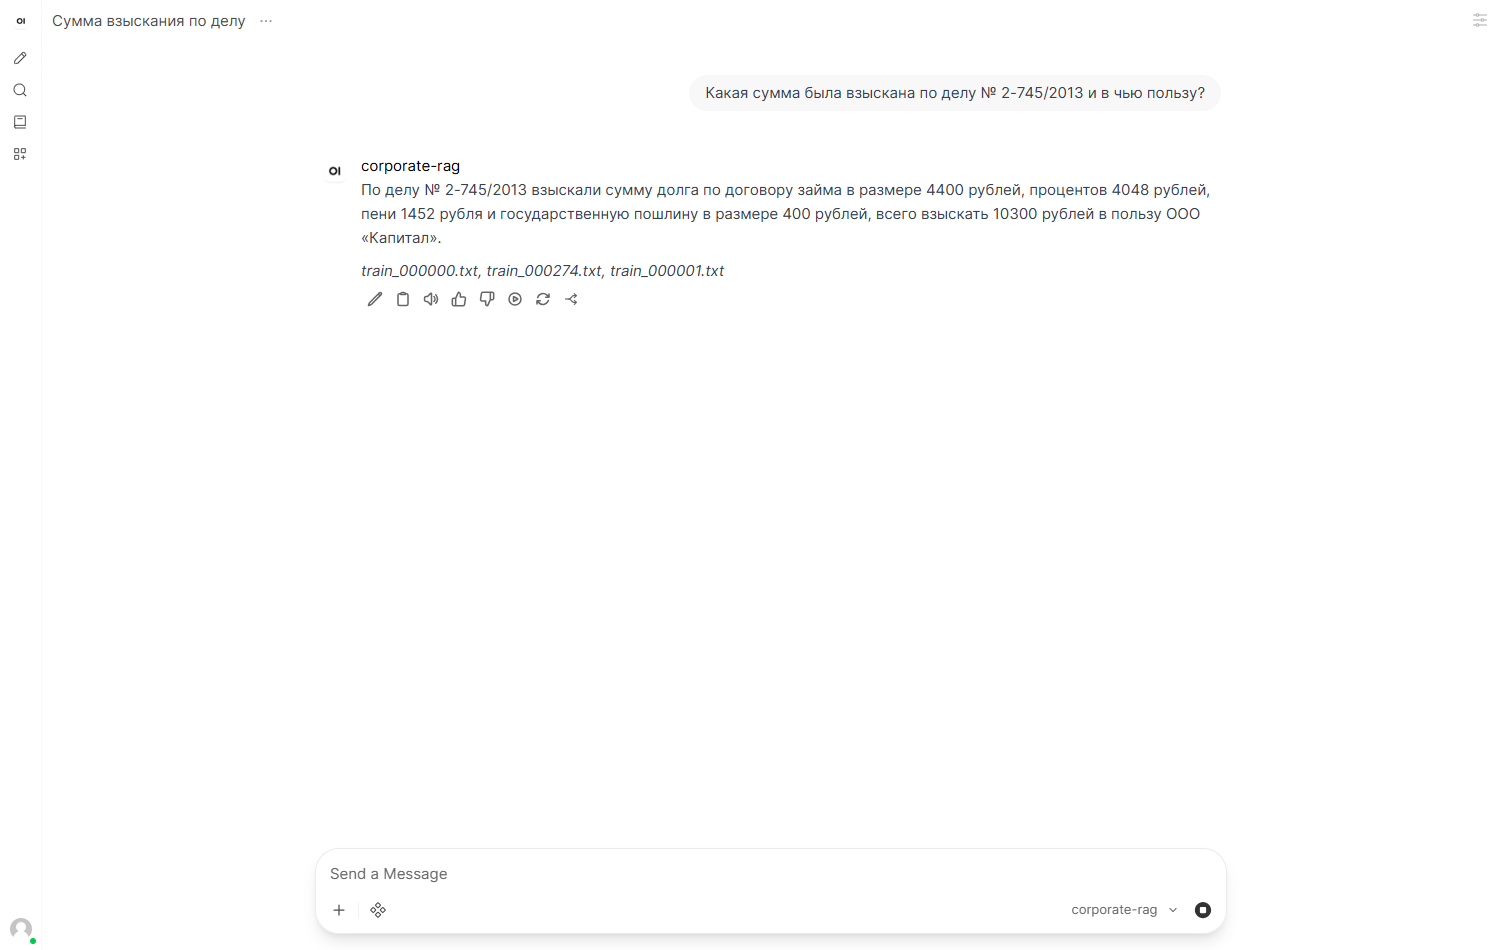

Запрос вне базы — корректный отказ


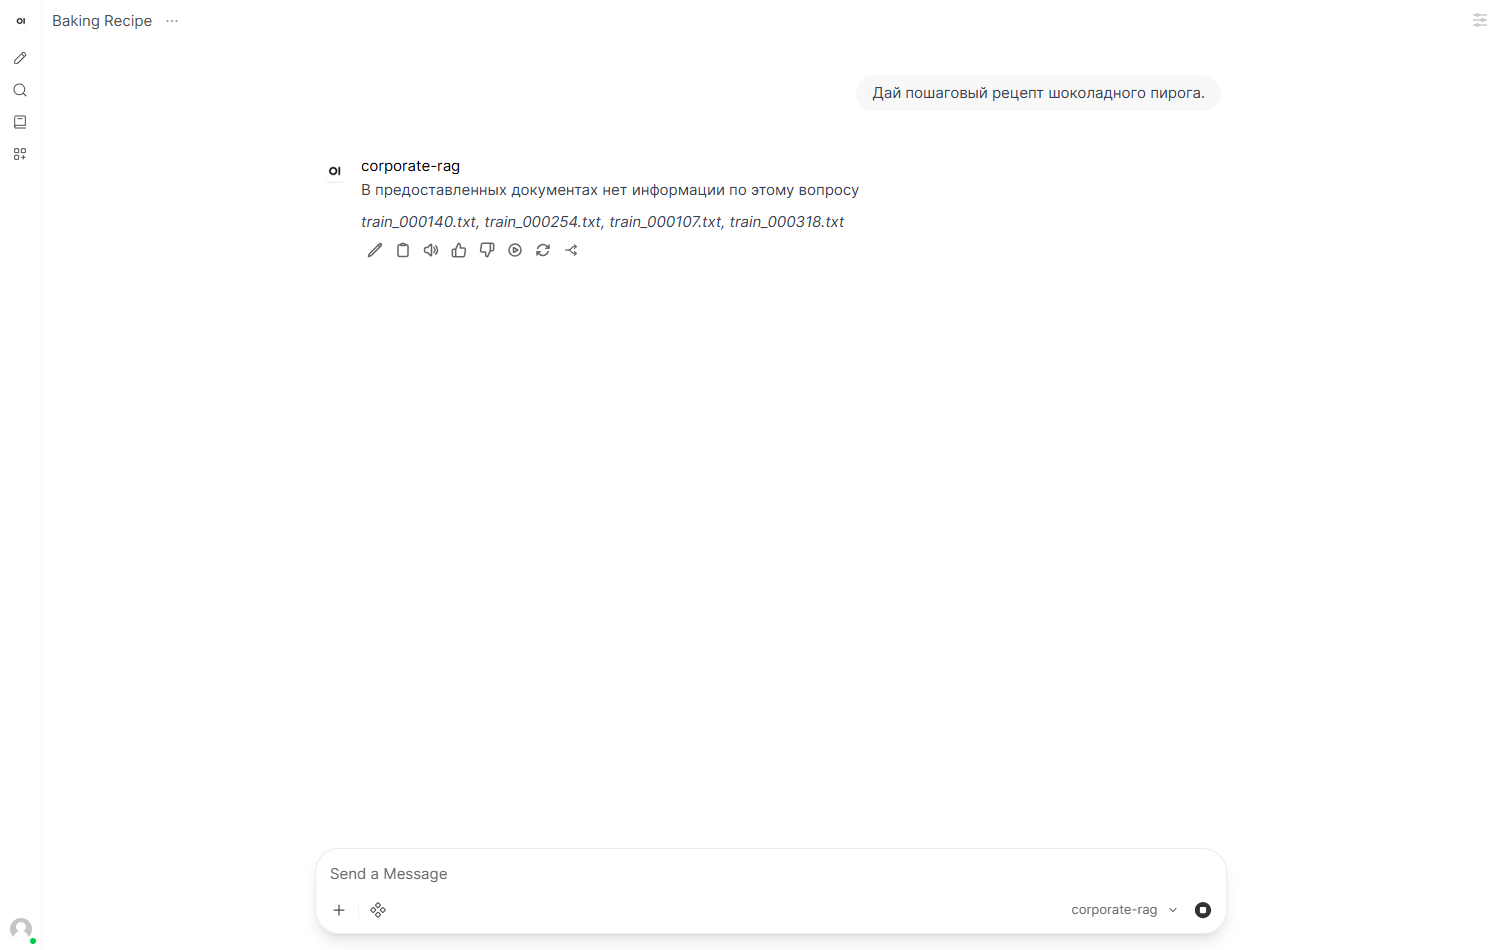

Конфликт фактов — приоритет документа


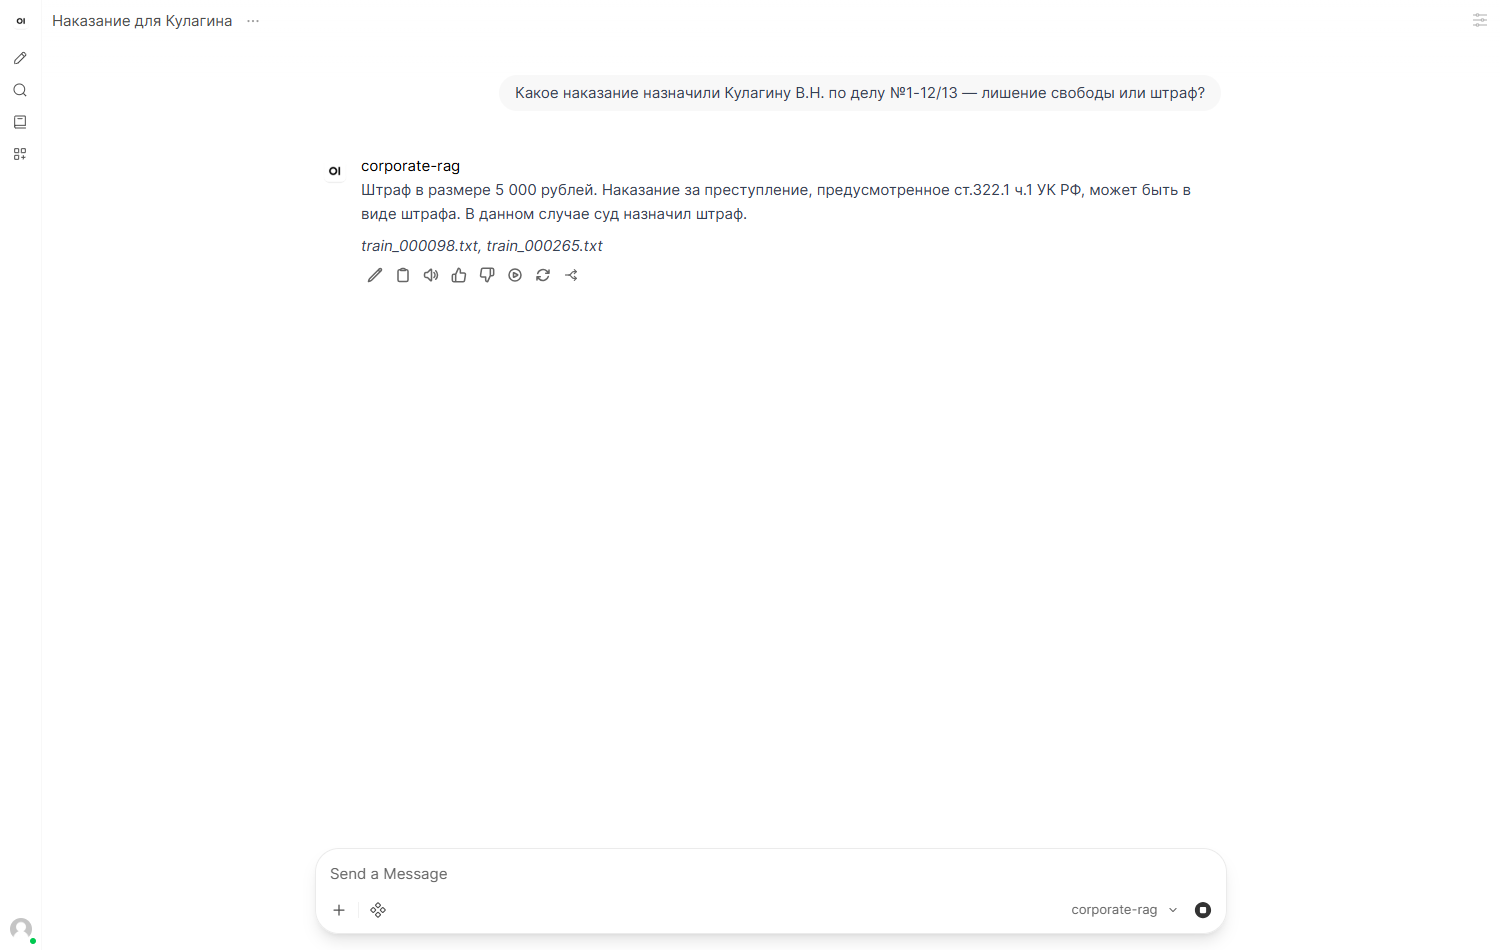

In [7]:
from IPython.display import Image, display
for name, caption in [
    ("01_po_baze.png", "Запрос по базе — верный факт из документа"),
    ("02_vne_bazy.png", "Запрос вне базы — корректный отказ"),
    ("03_konflikt.png", "Конфликт фактов — приоритет документа"),
]:
    p = ROOT / "notes" / "screenshots" / name
    if p.exists():
        print(caption)
        display(Image(filename=str(p)))

## 8. Анализ слабых мест и выводы

**Слабые места**

- **Галлюцинации.** При K=8 в контекст попадают нерелевантные дела, и модель
  иногда добавляет «Источники» даже в отказ. Строгий системный промпт и
  разумный K снижают риск, но не исключают его полностью.
- **Скорость.** На CPU без GPU ответ занимает от 5 до 60 с — главный
  компромисс локального развёртывания.
- **Качество эмбеддингов.** `e5-small` иногда ставит в топ похожие по
  формулировкам, но разные по сути дела.
- **Предобработка.** Юридические тексты анонимизированы (`<ДАТА1>`, `<АДРЕС>`),
  что усложняет точные фактологические вопросы.

**Трудности локального развёртывания (в сравнении с облачными API)**

- Нет GPU → медленная генерация; пришлось выбрать модель 3B вместо 7B+.
- `open-webui` не поддерживает Python 3.13 → отдельное окружение на Python 3.12.
- Первичная индексация 3813 чанков на CPU заняла ~12 минут.

**Защита данных**

Система действительно изолирована: LLM, эмбеддинги и ChromaDB работают
локально; наружу уходят только разовые загрузки моделей и датасета при
установке. После установки пайплайн работает офлайн, конфиденциальные
документы и запросы не передаются третьим лицам. Ограничения — физическая
безопасность машины и отсутствие внешнего API-аудита, что решается
организационными мерами.

**Итог:** критерии задания выполнены — реализована связка «векторная БД + LLM»
(RAG), чат-бот отвечает строго по загруженным документам, предоставлен рабочий
интерфейс и инструкция по запуску.
